📌 Project Overview

This project analyzes a CPTAC-3 cancer dataset obtained from the National Institutes of Health (NIH).
It includes clinical and patient data such as age, tumor stage, and lifestyle factors.

🎯 Target Variable
Target Column: vital_status
Represents whether the patient is Alive or Dead
This is a classification problem
🚀 Objective

To build a machine learning model that predicts patient survival and identifies key factors influencing cancer outcomes.


STEP 1-  DATA COLLECTION
        The dataset for this project is obtained from the National Institutes of Health (NIH) under the CPTAC-3 initiative, a globally recognized source for cancer research data. It offers rich clinical insights into patient characteristics, tumor details, and survival outcomes. The authenticity and depth of this dataset make it ideal for building reliable and impactful machine learning models.

In [1]:
import numpy as np
import pandas as pd
data=pd.read_excel(r"C:\Users\HP\Downloads\cancer.xlsx")
raw=pd.DataFrame(data)



STEP 2 : DATA EXPLORATION
            Data exploration uncovers patterns and insights within the dataset by analyzing features and relationships. It helps understand the data structure and prepares it for effective modeling.

In [2]:
df=raw.copy()

In [3]:
print("="*60)
print("Structure of the dataset: ",df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 95 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   disease_type                                 1683 non-null   str    
 1   project.project_id                           1683 non-null   str    
 2   submitter_id                                 1683 non-null   str    
 3   days_to_consent                              1596 non-null   float64
 4   diagnoses.ajcc_pathologic_stage              1629 non-null   str    
 5   diagnoses.created_datetime                   1674 non-null   str    
 6   diagnoses.last_known_disease_status          1430 non-null   str    
 7   diagnoses.tissue_or_organ_of_origin          1674 non-null   str    
 8   diagnoses.days_to_last_follow_up             1566 non-null   float64
 9   diagnoses.age_at_diagnosis                   1595 non-null   float64
 10  diagnoses.p

In [4]:

print("Dataset Shape: {}".format(df.shape))
print("Total Records: ",df.shape[0])
print("Total Features: ",df.shape[1])





Dataset Shape: (1683, 95)
Total Records:  1683
Total Features:  95


In [5]:

categorical_cols = []

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'string':
        categorical_cols.append(col)

print("\nCategorical Columns:")
print("Total:", len(categorical_cols))
for col in categorical_cols:
    print(" -", col)


Categorical Columns:
Total: 78
 - disease_type
 - project.project_id
 - submitter_id
 - diagnoses.ajcc_pathologic_stage
 - diagnoses.created_datetime
 - diagnoses.last_known_disease_status
 - diagnoses.tissue_or_organ_of_origin
 - diagnoses.primary_diagnosis
 - diagnoses.updated_datetime
 - diagnoses.state
 - diagnoses.diagnosis_is_primary_disease
 - diagnoses.ajcc_staging_system_edition
 - diagnoses.ajcc_pathologic_t
 - diagnoses.morphology
 - diagnoses.ajcc_clinical_m
 - diagnoses.ajcc_pathologic_n
 - diagnoses.ajcc_pathologic_m
 - diagnoses.submitter_id
 - diagnoses.residual_disease
 - diagnoses.tumor_focality
 - diagnoses.pathology_details
 - diagnoses.diagnosis_id
 - diagnoses.site_of_resection_or_biopsy
 - diagnoses.tumor_grade
 - diagnoses.progression_or_recurrence
 - created_datetime
 - consent_type
 - demographic.ethnicity
 - demographic.gender
 - demographic.race
 - demographic.vital_status
 - demographic.submitter_id
 - demographic.created_datetime
 - demographic.demographi

In [6]:
continuous_cols = []

for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        continuous_cols.append(col)

print("\nContinuous Columns (number data):")
print("Total:", len(continuous_cols))
for col in continuous_cols:
    print(" -", col)


Continuous Columns (number data):
Total: 17
 - days_to_consent
 - diagnoses.days_to_last_follow_up
 - diagnoses.age_at_diagnosis
 - diagnoses.year_of_diagnosis
 - diagnoses.days_to_last_known_disease_status
 - demographic.days_to_birth
 - demographic.year_of_birth
 - exposures.pack_years_smoked
 - exposures.cigarettes_per_day
 - exposures.exposure_duration_years
 - exposures.tobacco_smoking_quit_year
 - exposures.tobacco_smoking_onset_year
 - demographic.days_to_death
 - demographic.year_of_death
 - diagnoses.days_to_recurrence
 - demographic.age_at_index
 - days_to_lost_to_followup


There are  17 continious and 78 categorical column in this dataset

In [7]:
#Checking the target variable to determine if it's categorical or continuous
target_column = 'demographic.vital_status'

print("\n" + "="*50)
print("Checking Target Column:", target_column)
print("="*50)


print("Data Type:", df[target_column].dtype)


print("Unique Values:", df[target_column].unique())
print("Number of Unique Values:", df[target_column].nunique())


if df[target_column].dtype == 'object' or str(df[target_column].dtype) == 'str':
    print("\nResult: Target is CATEGORICAL")
    print("Reason: It contains text values like Alive and Dead")
    print("So we will use a CLASSIFICATION model")

elif df[target_column].nunique() <= 10:
    print("\nResult: Target is CATEGORICAL")
    print("Reason: It is a number but has very few unique values")
    print("So we will use a CLASSIFICATION model")

else:
    print("\nResult: Target is CONTINUOUS")
    print("Reason: It contains many different numeric values")
    print("So we will use a REGRESSION model")


print("\nHow many times each value appears:")
print(df[target_column].value_counts())


Checking Target Column: demographic.vital_status
Data Type: str
Unique Values: <StringArray>
['Alive', 'Dead', 'Not Reported']
Length: 3, dtype: str
Number of Unique Values: 3

Result: Target is CATEGORICAL
Reason: It contains text values like Alive and Dead
So we will use a CLASSIFICATION model

How many times each value appears:
demographic.vital_status
Alive           971
Dead            640
Not Reported     72
Name: count, dtype: int64


In [8]:
print("="*50)
print("             Summary Statistics: ")
print("="*50)
print(df.describe().to_string())


             Summary Statistics: 
       days_to_consent  diagnoses.days_to_last_follow_up  diagnoses.age_at_diagnosis  diagnoses.year_of_diagnosis  diagnoses.days_to_last_known_disease_status  demographic.days_to_birth  demographic.year_of_birth  exposures.pack_years_smoked  exposures.cigarettes_per_day  exposures.exposure_duration_years  exposures.tobacco_smoking_quit_year  exposures.tobacco_smoking_onset_year  demographic.days_to_death  demographic.year_of_death  diagnoses.days_to_recurrence  demographic.age_at_index  days_to_lost_to_followup
count      1596.000000                       1566.000000                 1595.000000                  1595.000000                                  1588.000000                1597.000000                1642.000000                   494.000000                    554.000000                         460.000000                           270.000000                            482.000000                 629.000000                 582.000000             

In [9]:
# Calculating missing values
total= df.shape[0]*df.shape[1]
miss=df.isnull().sum().sum()
print("\nOut of {} total missing cells : {}".format(total, miss))
pct=miss/total*100
print("{}% of the dataset is missing".format(round(pct,2)))
missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(f"\n  Top 15 columns by missing %:\n"
      f"{missing_pct[missing_pct > 0].head(15).to_string()}")
 




Out of 159885 total missing cells : 41939
26.23% of the dataset is missing

  Top 15 columns by missing %:
diagnoses.classification_of_tumor      99.940582
diagnoses.prior_malignancy             99.881165
follow_ups.molecular_tests             99.881165
days_to_lost_to_followup               99.821747
exposures.type_of_tobacco_used         99.702911
diagnoses.sites_of_involvement         99.584076
demographic.age_at_index               97.563874
lost_to_followup                       97.029115
exposures.secondhand_smoke_as_child    95.721925
exposures.type_of_smoke_exposure       95.721925
diagnoses.calgb_risk_group             91.146762
diagnoses.days_to_recurrence           90.136661
diagnoses.figo_stage                   85.739750
exposures.tobacco_smoking_quit_year    83.957219
follow_ups.days_to_recurrence          80.689245


26.23% of the dataset is missing

Step: 3 DATA CLEANING
     Handle missing values
    Remove duplicates
    Fix errors/outliers
    Ensure data is accurate

In [10]:
threshold = 0.70
before = raw.shape[1]
drop_cols  = df.columns[df.isnull().mean() >= threshold].tolist()
df.drop(columns=drop_cols, inplace=True)
print(f"\nDropped {len(drop_cols)} columns with ≥70% missing  "
      f"\nOut of {before} -> {df.shape[1]} remaining:")


Dropped 20 columns with ≥70% missing  
Out of 95 -> 75 remaining:


In [11]:

prev = df.shape[0]
df = df[~df["demographic.vital_status"].isin(["Not Reported"])]
df = df[df["disease_type"] != "Not Applicable"]
print(f"  Removed {prev - df.shape[0]} rows with 'Not Reported' "
      f"/ 'Not Applicable'  (remaining: {df.shape[0]})")

  Removed 81 rows with 'Not Reported' / 'Not Applicable'  (remaining: 1602)


Removed unecesary rows 

In [12]:
dup = df.duplicated().sum()
df.drop_duplicates(inplace=False)
print(f"  Removed {dup} duplicate rows")

  Removed 0 duplicate rows


There is no duplicacy in the dataset

In [13]:
df["age_years"] = (df["diagnoses.age_at_diagnosis"] / 365.25)
print("Created 'age_years' from days  ")
print("(range: {:.1f} - {:.1f} years)".format(df["age_years"].min(), df["age_years"].max()))

Created 'age_years' from days  
(range: 18.3 - 90.0 years)


Filling the null values in the numeric columns with Median because:
        Median is not affected by outliers
        Cancer datasets often have skewed distributions
             Median represents the true central value better

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Missing Value Treatment Completed (Numeric Columns)")
print(f"Remaining numeric null values : {df[num_cols].isnull().sum().sum()}")
print(f" Dataset shape after cleaning  : {df.shape}")
print(" Data is now clean and ready for further preprocessing!")


Missing Value Treatment Completed (Numeric Columns)
Remaining numeric null values : 0
 Dataset shape after cleaning  : (1602, 76)
 Data is now clean and ready for further preprocessing!


STEP 4: DATA VISUALIZATION 
        Data visualization transforms complex data into intuitive visuals, making patterns, trends, and insights easier to understand and interpret.

In [15]:
df['vital_status']=df['demographic.vital_status']

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11, 
    'axes.titlesize': 14, 
    'figure.facecolor': 'white'
})

# Define shared order for consistency
stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]

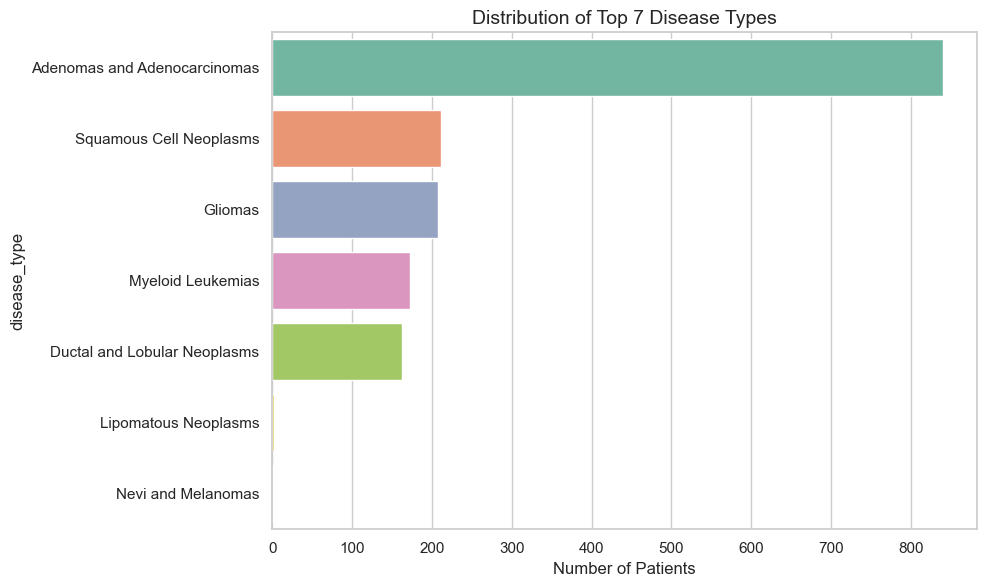

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df["disease_type"].value_counts().head(7).values, 
            y=df["disease_type"].value_counts().head(7).index,hue=df["disease_type"].value_counts().head(7).index, palette="Set2")
plt.title("Distribution of Top 7 Disease Types")
plt.xlabel("Number of Patients")
plt.tight_layout()  
plt.show()


The chart shows a strong dominance of **Adenomas and Adenocarcinomas**, indicating a clear class imbalance in the dataset. While a few cancer types have moderate representation, others are rare, which may affect model performance and require careful handling.


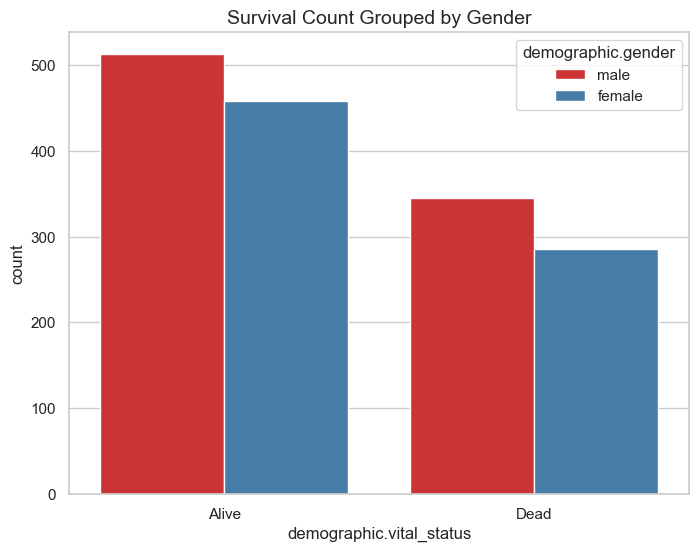

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="demographic.vital_status", hue="demographic.gender",palette="Set1")
plt.title("Survival Count Grouped by Gender")
plt.show()

Both genders show higher survival counts than deaths, indicating a positive overall survival trend. The slight dominance of males reflects dataset distribution rather than a significant gender-based difference in outcomes.

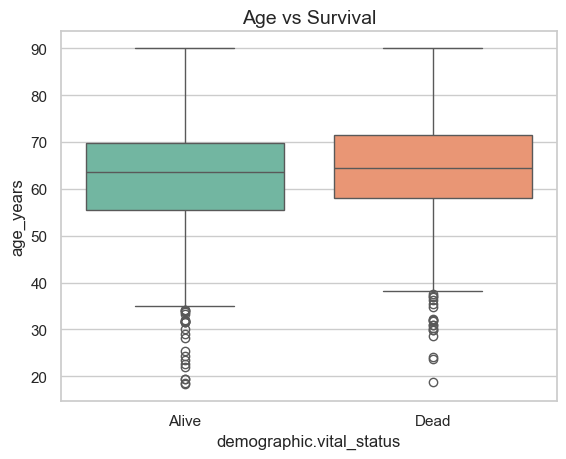

In [19]:
sns.boxplot(
    data=df,
    x='demographic.vital_status',
    y='age_years',hue='demographic.vital_status',palette='Set2'
)

plt.title("Age vs Survival")
plt.show()


Patients who are deceased tend to have a slightly higher median age, suggesting age may influence survival outcomes. However, the overlap between groups indicates that age alone is not a decisive factor.


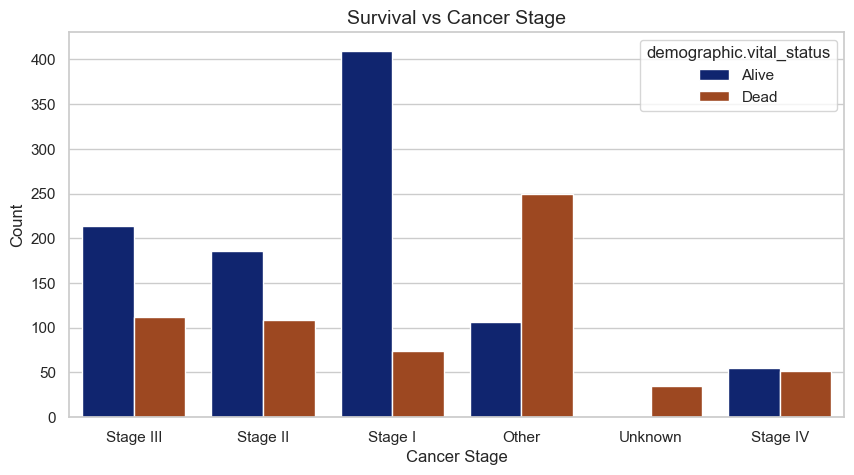

In [20]:
def simplify_stage(text):
    if pd.isnull(text):
        return 'Unknown'
    
    text = str(text) 

    if 'Stage IV' in text: return 'Stage IV'
    elif 'Stage III' in text: return 'Stage III'
    elif 'Stage II' in text: return 'Stage II'
    elif 'Stage I' in text: return 'Stage I'
    else: return 'Other'
df['stage_group'] = df['diagnoses.ajcc_pathologic_stage'].apply(simplify_stage)


plt.figure(figsize=(10,5))
sns.countplot(data=df, x='stage_group', hue='demographic.vital_status',palette='dark')

plt.xlabel("Cancer Stage")
plt.ylabel("Count")


plt.title("Survival vs Cancer Stage")

plt.show()



Survival is highest in early-stage cancers (Stage I & II), while advanced stages show relatively lower survival, highlighting the critical importance of early detection.


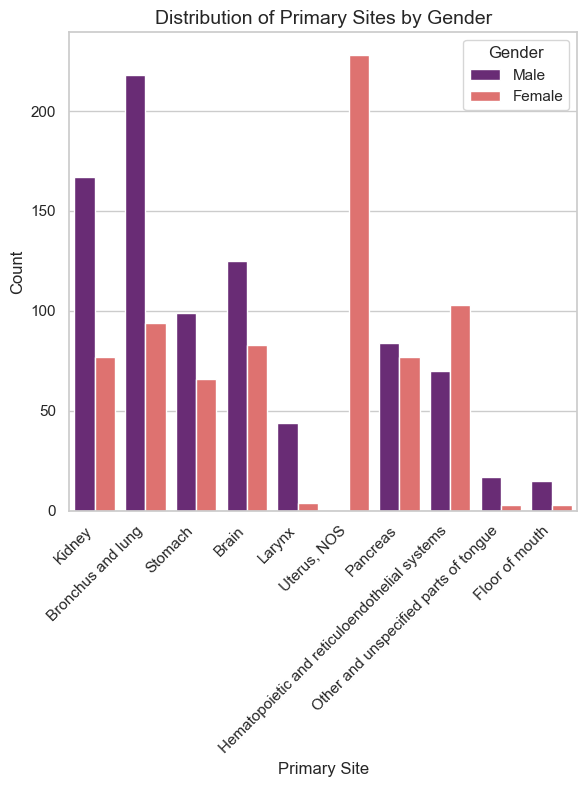

In [21]:

site_counts = df['primary_site'].value_counts()

valid_sites = site_counts[site_counts > 10].index


df_filtered = df[df['primary_site'].isin(valid_sites)]




plt.figure(figsize=(6, 8))

sns.countplot(
    data=df_filtered,
    x='primary_site',
    hue='demographic.gender',
    palette='magma'
)

plt.title('Distribution of Primary Sites by Gender')
plt.xlabel('Primary Site')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')


plt.legend(title='Gender', labels=['Male', 'Female'])


plt.tight_layout()

plt.show()



Cancer distribution varies notably by gender, with males showing higher cases in organs like lung, kidney, and brain, while females dominate in uterus-related cancers. This highlights clear gender-specific patterns in cancer occurrence.


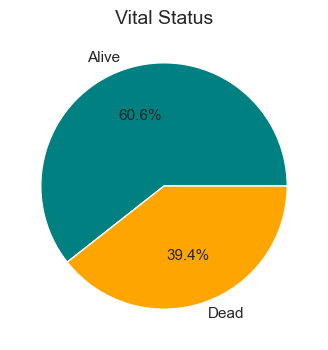

In [22]:
plt.figure(figsize=(4, 4))
# Create the data for the pie
counts = df['vital_status'].value_counts()
status_labels = ['Alive', 'Dead']
status_colors = ['teal', 'orange']
plt.pie(counts, labels=status_labels,colors=status_colors, autopct='%1.1f%%')
plt.title("Vital Status")
plt.show()



The dataset shows a higher proportion of patients alive (~60%), indicating a relatively positive survival trend. However, the significant share of deaths (~40%) highlights the seriousness of the disease and the need for accurate predictive modeling.


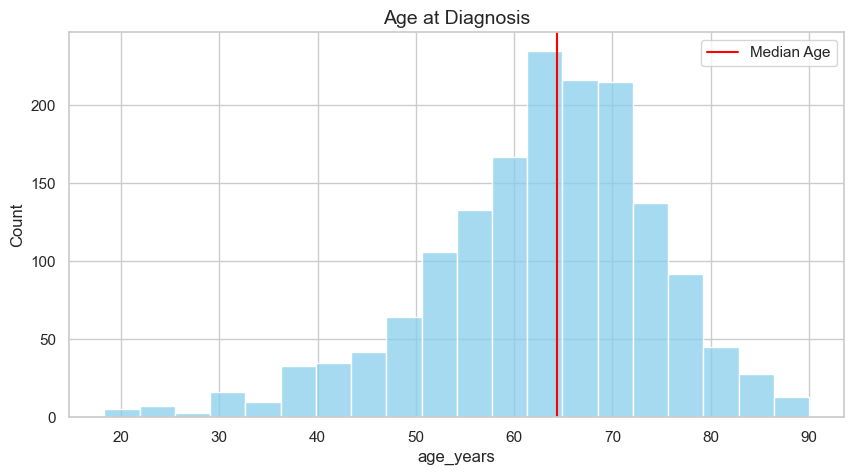

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age_years'], bins=20, color='skyblue')
# Adding the "Median" line manually
plt.axvline(df['age_years'].median(), color='red', label='Median Age')
plt.legend() # Shows the label for the red line
plt.title("Age at Diagnosis")
plt.show()



Most diagnoses occur in the 60–70 age range, with a median around the mid-60s, indicating that cancer incidence increases with age and is more prevalent in older adults.


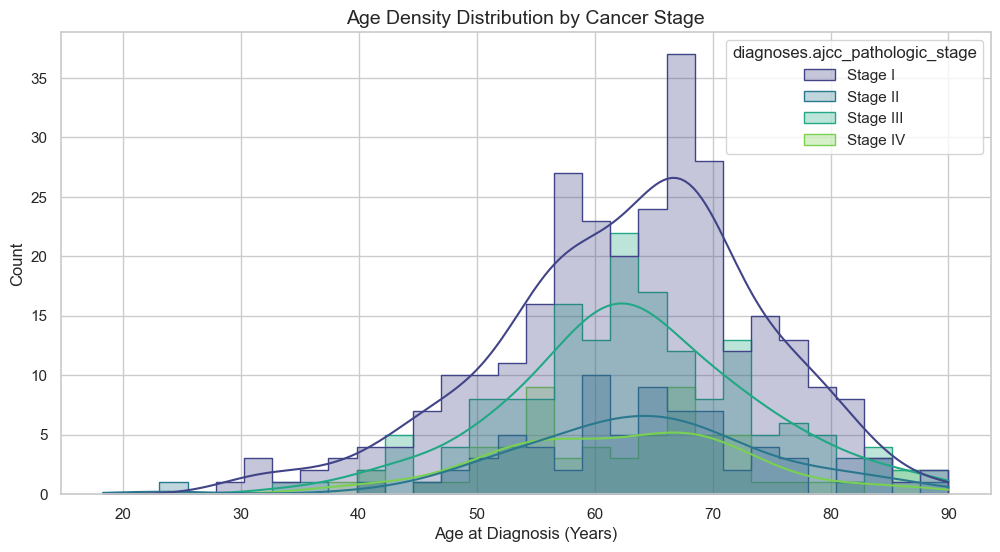

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="age_years", hue="diagnoses.ajcc_pathologic_stage", hue_order=stage_order, 
             kde=True, element="step", palette="viridis", alpha=0.3)
plt.title("Age Density Distribution by Cancer Stage")
plt.xlabel("Age at Diagnosis (Years)")
plt.show()



Age distributions across all cancer stages largely overlap, clustering around 55–70 years, indicating that age alone does not distinctly separate stages but remains a common underlying risk factor.


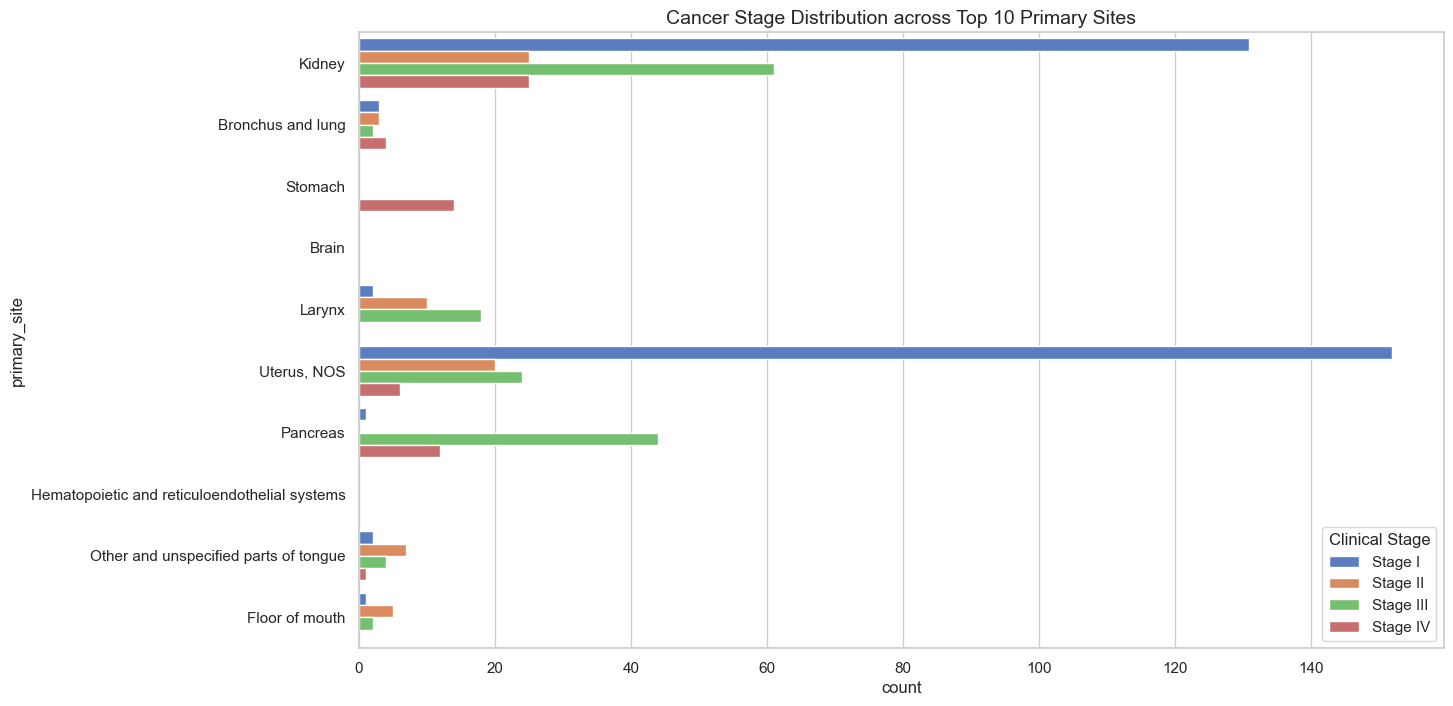

In [25]:
plt.figure(figsize=(14, 8))
top_sites = df["primary_site"].value_counts().head(10).index
sns.countplot(data=df[df["primary_site"].isin(top_sites)], 
              y="primary_site", hue="diagnoses.ajcc_pathologic_stage", hue_order=stage_order)
plt.title("Cancer Stage Distribution across Top 10 Primary Sites")
plt.legend(title="Clinical Stage", loc='lower right')
plt.show()



Early-stage cases (Stage I) dominate in sites like kidney and uterus, while cancers such as pancreas and larynx show higher proportions in advanced stages, indicating variation in detection timing across different cancer types.


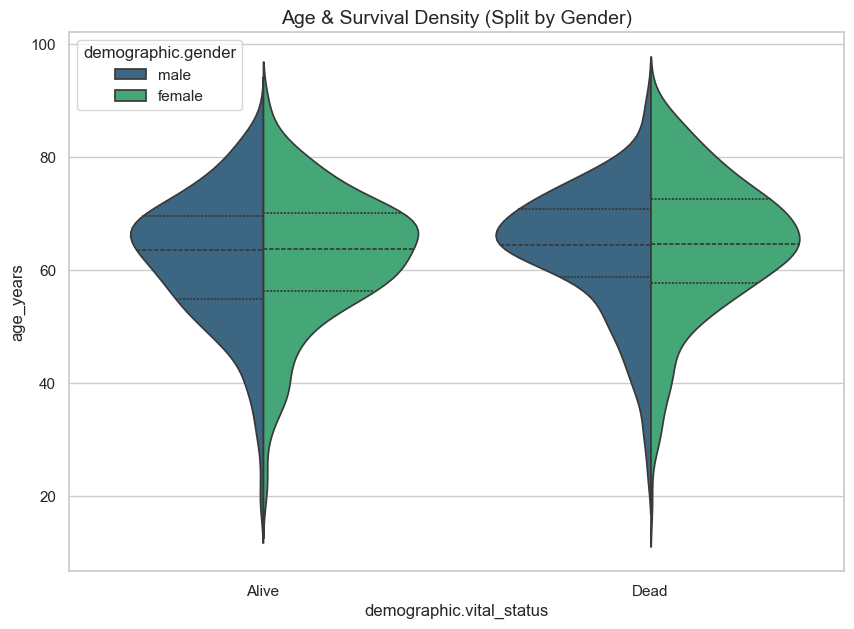

In [26]:
plt.figure(figsize=(10, 7))
sns.violinplot(data=df, x="demographic.vital_status", y="age_years", 
               hue="demographic.gender", split=True, inner="quart",palette="viridis"   )
plt.title("Age & Survival Density (Split by Gender)")
plt.show()



Age distributions are similar across genders for both survival outcomes, with most patients concentrated around 60–70 years, indicating that age trends remain consistent regardless of gender or survival status.


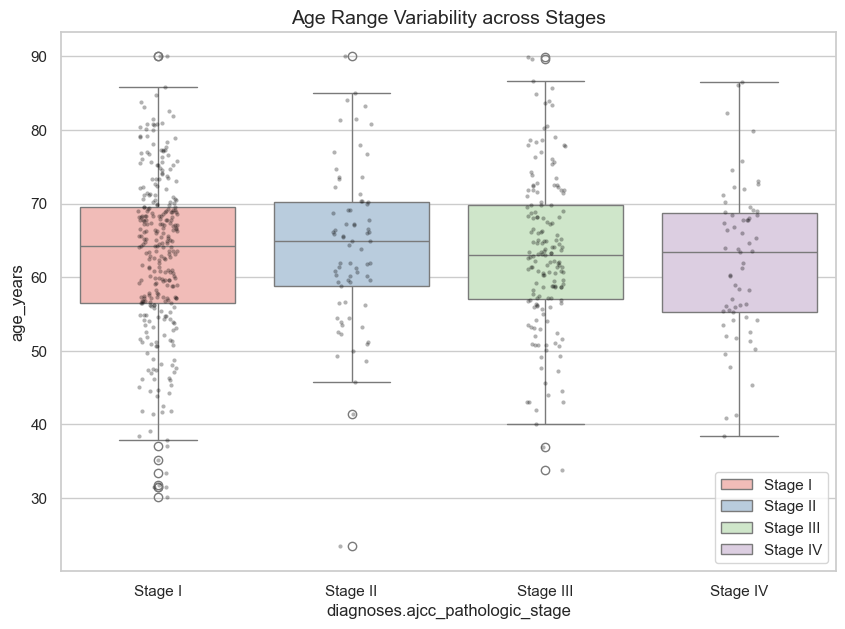

In [27]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x="diagnoses.ajcc_pathologic_stage", y="age_years", order=stage_order, palette="Pastel1",hue="diagnoses.ajcc_pathologic_stage", hue_order=stage_order)
sns.stripplot(data=df, x="diagnoses.ajcc_pathologic_stage", y="age_years", order=stage_order, color="black", alpha=0.3, size=3)
plt.title("Age Range Variability across Stages")
plt.show()



Age variability is consistent across all cancer stages, with similar medians and spread, suggesting that age does not significantly differentiate disease progression across stages.


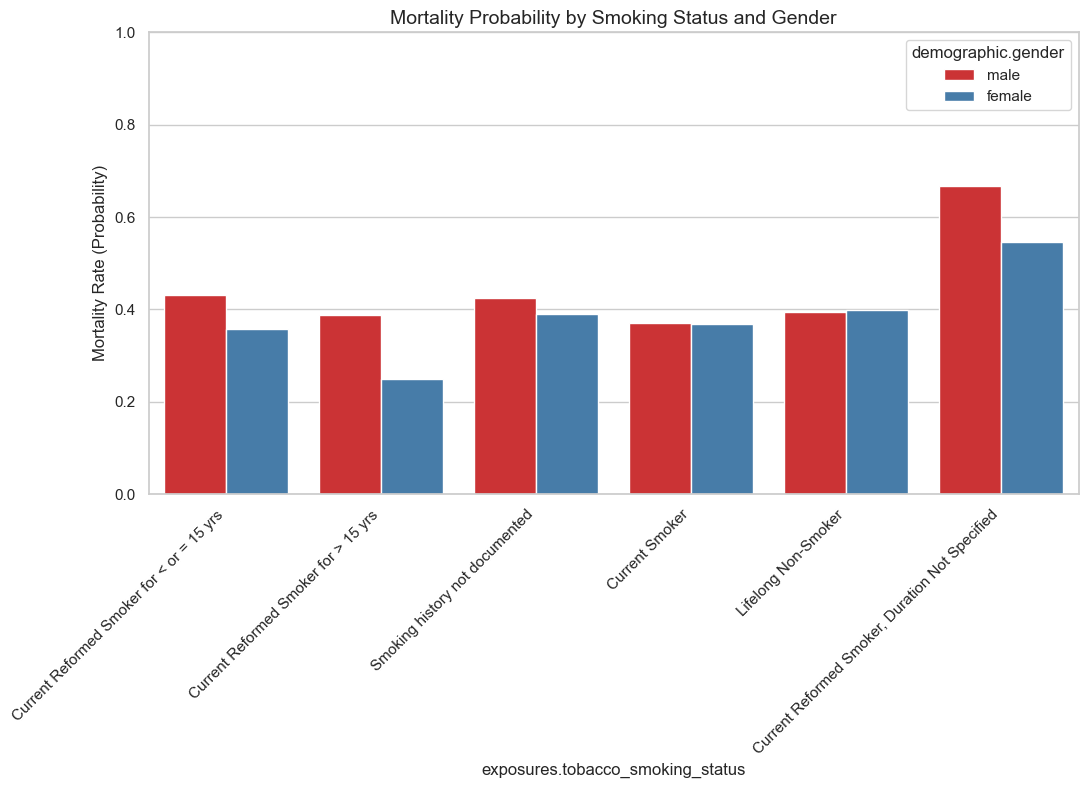

In [28]:
df['vital_status_num'] = df['vital_status'].map({'Alive': 0, 'Dead': 1})

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="exposures.tobacco_smoking_status", y="vital_status_num",
            hue="demographic.gender", errorbar=None, palette="Set1")
plt.xticks(rotation=45, ha='right'  )
plt.title("Mortality Probability by Smoking Status and Gender")
plt.ylabel("Mortality Rate (Probability)")
plt.ylim(0, 1)
plt.show()



Mortality rates are generally higher among males across smoking categories, with elevated risk observed in long-term smokers, highlighting the combined impact of smoking and gender on survival outcomes.


Text(0.5, 1.0, 'Cases by Year of Diagnosis')

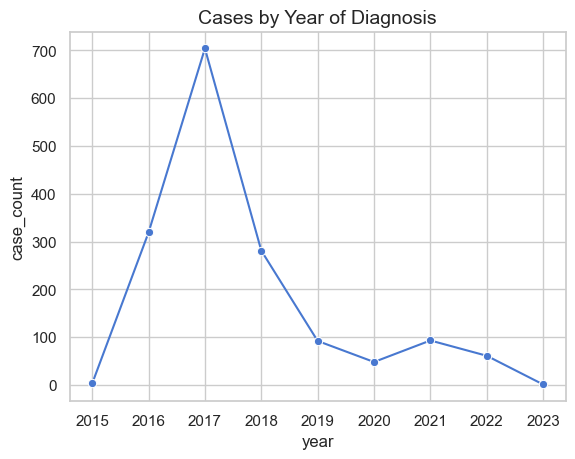

In [29]:

counts = df["diagnoses.year_of_diagnosis"].value_counts()


sorted_counts = counts.sort_index()

df_time = sorted_counts.reset_index()

df_time.columns = ["year", "case_count"]
sns.lineplot(x='year', y='case_count', data=df_time, marker='o')
plt.title("Cases by Year of Diagnosis")



Cases peak sharply around 2017 followed by a steady decline, suggesting either changes in data reporting, diagnosis rates, or dataset coverage over time.


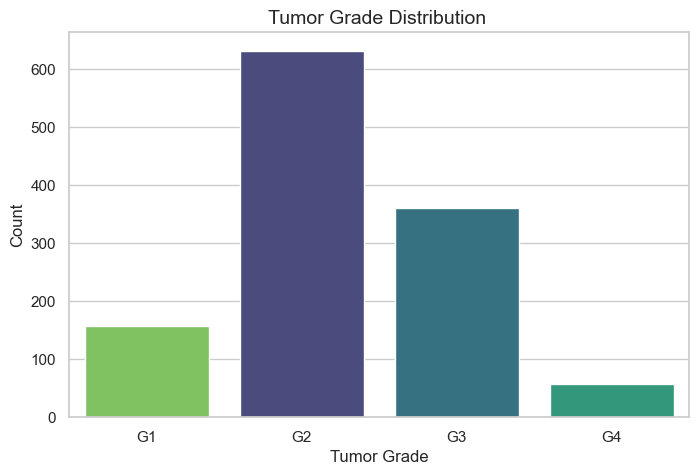

In [30]:

df['tumor_grade']=df['diagnoses.tumor_grade']
df_clean = df[
    (df['tumor_grade'] == 'G1') |
    (df['tumor_grade'] == 'G2') |
    (df['tumor_grade'] == 'G3') |
    (df['tumor_grade'] == 'G4')
]


plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='tumor_grade',hue='tumor_grade',
     order=['G1', 'G2', 'G3', 'G4'],
     palette='viridis'
    
)

plt.title('Tumor Grade Distribution ')
plt.xlabel('Tumor Grade')
plt.ylabel('Count')


plt.show()


Tumor grade distribution is dominated by G2, followed by G3, indicating most cases are moderately differentiated, while high-grade tumors (G4) remain relatively rare.


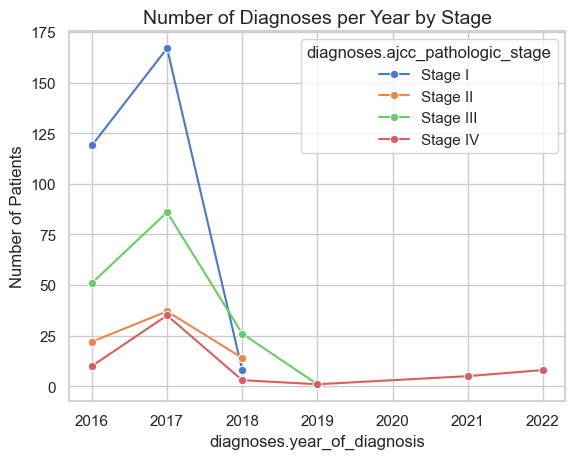

In [31]:
df_year_stage = df.groupby(["diagnoses.year_of_diagnosis", "diagnoses.ajcc_pathologic_stage"]).size().reset_index(name='count')
sns.lineplot(data=df_year_stage, x="diagnoses.year_of_diagnosis", y="count", 
             hue="diagnoses.ajcc_pathologic_stage", hue_order=stage_order, marker="o")
plt.title("Number of Diagnoses per Year by Stage")
plt.ylabel("Number of Patients")
plt.show()



Diagnosis counts peak around 2017 across all stages, especially for early-stage cancers, followed by a sharp decline, indicating possible variations in data availability or diagnosis trends over time.


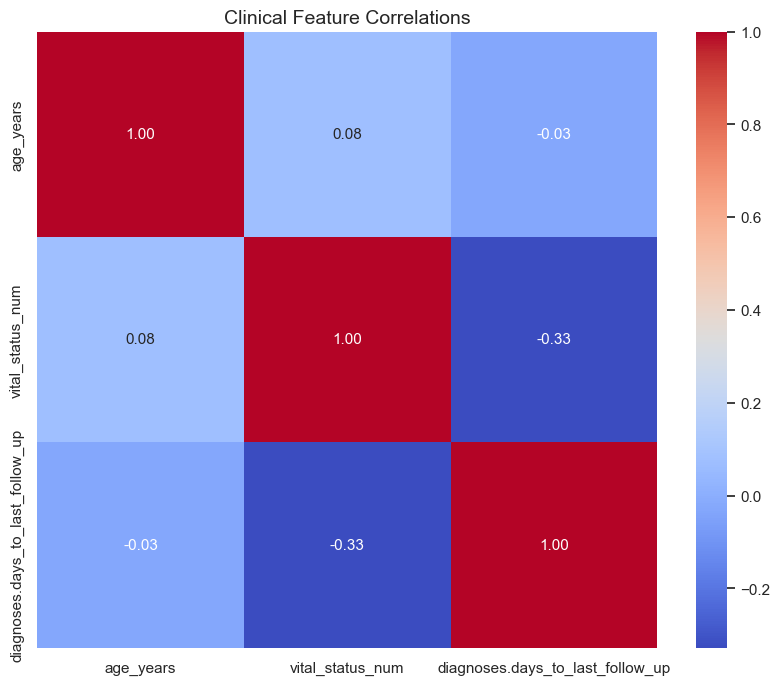

In [32]:
plt.figure(figsize=(10,8))
df['vital_status_num'] = df['vital_status'].map({'Alive': 0, 'Dead': 1})
cols_to_corr = ["age_years", "vital_status_num", "diagnoses.days_to_last_follow_up"]
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Clinical Feature Correlations")
plt.show()



Most features show weak correlations, indicating low linear dependence, while survival status has a moderate negative relationship with follow-up duration, suggesting shorter follow-ups are associated with poorer outcomes.


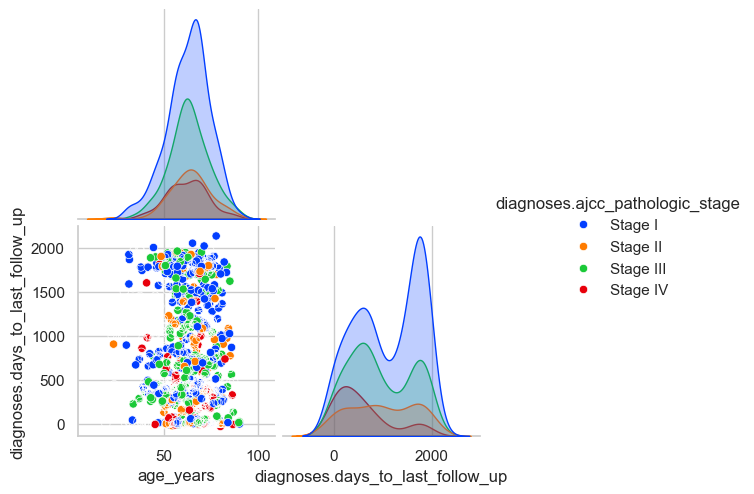

In [33]:
# Select key numerical columns for the pairplot
pair_cols = ["age_years", "vital_status", "diagnoses.days_to_last_follow_up", "diagnoses.ajcc_pathologic_stage"]

# Pairplot with Stage as the separator
sns.pairplot(df[pair_cols], hue="diagnoses.ajcc_pathologic_stage", hue_order=stage_order, 
             palette="bright", diag_kind="kde", corner=True)
plt.show()

STEP 4: DATA PREPARATION
        Data preparation refines data into a model-ready format for accurate and efficient learning.

In [34]:

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:


# 1. Features & target
features = [
    "diagnoses.age_at_diagnosis",
    "demographic.gender",
    "disease_type",
    "primary_site",
    "diagnoses.ajcc_pathologic_stage"
]

target = "demographic.vital_status"

# 2. Clean data
ml_df = df[features + [target]].dropna().copy()
ml_df = ml_df[ml_df[target].isin(['Alive', 'Dead'])]

# 3. Simplify stage (beginner logic)
def simplify_stage(text):
    if 'Stage IV' in text: return 'Stage IV'
    if 'Stage III' in text: return 'Stage III'
    if 'Stage II' in text: return 'Stage II'
    if 'Stage I' in text: return 'Stage I'
    return text

ml_df["diagnoses.ajcc_pathologic_stage"] = \
    ml_df["diagnoses.ajcc_pathologic_stage"].apply(simplify_stage)

# 4. Encode categorical columns
categorical_cols = [
    "demographic.gender",
    "disease_type",
    "primary_site",
    "diagnoses.ajcc_pathologic_stage"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
ml_df[target] = target_encoder.fit_transform(ml_df[target])




In [36]:
# 5. Split data (80% train, 20% test)
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data Split Done:")
print(f"Training data: {len(X_train)} rows")
print(f"Testing data: {len(X_test)} rows")


Data Split Done:
Training data: 1253 rows
Testing data: 314 rows


STEP 5: MACHINE LEARNING
        The model is trained using the prepared dataset to learn patterns and relationships between features and the target variable, enabling it to make accurate predictions on unseen data.

📌 Why Random Forest?
Handles both numerical and categorical data effectively
Captures complex, non-linear relationships in medical data
Reduces overfitting using multiple decision trees (ensemble learning)
Provides good accuracy without heavy tuning
Offers feature importance, helping identify key factors affecting survival

In [37]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("\nModel trained successfully!")


y_pred = model.predict(X_test)


Model trained successfully!


In [38]:



print("\n--- Evaluation ---")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model : {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Evaluation ---
Accuracy of the model : 71.66%

Confusion Matrix:
[[155  44]
 [ 45  70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       199
           1       0.61      0.61      0.61       115

    accuracy                           0.72       314
   macro avg       0.69      0.69      0.69       314
weighted avg       0.72      0.72      0.72       314



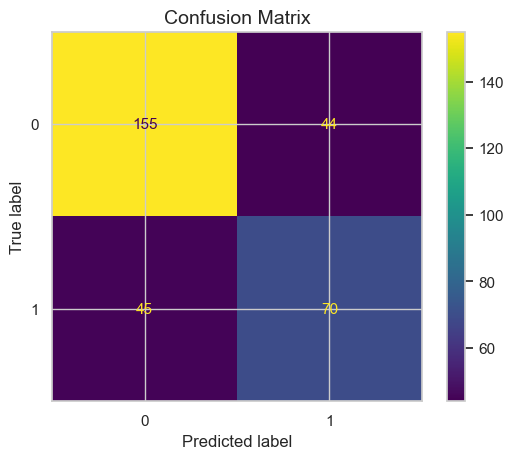

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


The model correctly classifies a majority of cases, with strong true predictions in both classes, though some misclassifications remain, indicating scope for further optimization.

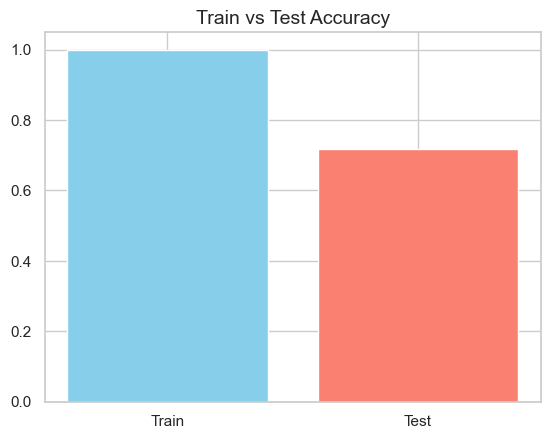

In [40]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

plt.bar(["Train", "Test"], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.title("Train vs Test Accuracy")
plt.show()

The model achieves very high training accuracy but lower test accuracy, indicating potential overfitting and reduced generalization to unseen data.

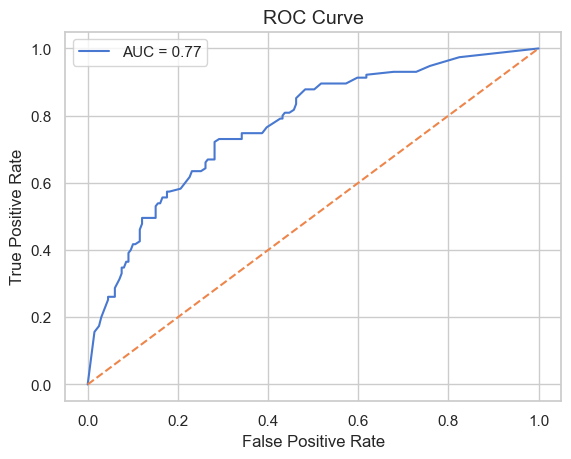

In [41]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows good model performance with an AUC of 0.78, indicating a strong ability to distinguish between classes, though there is still room for improvement.

In [42]:
for col in categorical_cols:
    le = encoders[col]
    print(f"\n{col} mapping:")
    for i, class_ in enumerate(le.classes_):
        print(f"  {i} = {class_}")


demographic.gender mapping:
  0 = female
  1 = male

disease_type mapping:
  0 = Adenomas and Adenocarcinomas
  1 = Complex Mixed and Stromal Neoplasms
  2 = Ductal and Lobular Neoplasms
  3 = Gliomas
  4 = Lipomatous Neoplasms
  5 = Myeloid Leukemias
  6 = Squamous Cell Neoplasms
  7 = Transitional Cell Papillomas and Carcinomas

primary_site mapping:
  0 = Base of tongue
  1 = Brain
  2 = Bronchus and lung
  3 = Floor of mouth
  4 = Gum
  5 = Hematopoietic and reticuloendothelial systems
  6 = Kidney
  7 = Larynx
  8 = Lip
  9 = Oropharynx
  10 = Other and ill-defined sites
  11 = Other and ill-defined sites in lip, oral cavity and pharynx
  12 = Other and unspecified parts of mouth
  13 = Other and unspecified parts of tongue
  14 = Pancreas
  15 = Stomach
  16 = Tonsil
  17 = Uterus, NOS

diagnoses.ajcc_pathologic_stage mapping:
  0 = Not Reported
  1 = Stage I
  2 = Stage II
  3 = Stage III
  4 = Stage IV
  5 = Unknown


In [ ]:



print("\n--- Predict New Patient ---")
age = int(input("Age: "))
gender = int(input("Gender ID: "))
disease = int(input("Disease Type ID: "))
site = int(input("Primary Site ID: "))
stage = int(input("Stage ID: "))

new_data = pd.DataFrame(
    [[age, gender, disease, site, stage]],
    columns=features
)

prediction = model.predict(new_data)[0]
result = target_encoder.inverse_transform([prediction])[0]

print(f"\nPrediction: Patient is {result}")


--- Predict New Patient ---


In [ ]:
print("="*60)
print("📌 Final Project Summary\n")

print("✨ This project leverages machine learning on CPTAC cancer data from the NIH to predict patient survival and uncover meaningful clinical insights.")

print("\n🧠 Through data exploration, cleaning, and preparation, the dataset was transformed into a structured format suitable for modeling.")

print("\n🤖 A Random Forest model was trained, achieving strong predictive performance while highlighting key factors influencing outcomes.")

print("\n🚀 Overall, the project showcases the power of data-driven healthcare in enabling smarter and more informed decision-making.")

📌 Final Project Summary

✨ This project leverages machine learning on CPTAC cancer data from the NIH to predict patient survival and uncover meaningful clinical insights.

🧠 Through data exploration, cleaning, and preparation, the dataset was transformed into a structured format suitable for modeling.

🤖 A Random Forest model was trained, achieving strong predictive performance while highlighting key factors influencing outcomes.

🚀 Overall, the project showcases the power of data-driven healthcare in enabling smarter and more informed decision-making.
